## Business problem:
A telecom company wants to reduce customer churn. I’ll analyze customer data, build a model to predict which customers are likely to leave, and identify the key drivers so the retention team can act.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [41]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
df.shape

(7043, 21)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [44]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

Missing TotalCharges: 11


In [ ]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [48]:
df.fillna({'TotalCharges': 0}, inplace=True)
print("Missing after fill:", df['TotalCharges'].isnull().sum())

Missing after fill: 0


In [49]:
df.drop(columns=['customerID'], inplace=True)

In [50]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [51]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df[['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']].nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

In [53]:
df['Contract'].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

In [54]:
print("Summary: 55% of customers are on month-to-month contracts and Churn rate is 26.5%")

Summary: 55% of customers are on month-to-month contracts and Churn rate is 26.5%


In [55]:
df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)

In [56]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

for col in cat_cols:
    churn_rate = df.groupby(col)['Churn_Flag'].mean().sort_values() * 100
    print(f"\nChurn rate by {col}:\n{churn_rate}")


Churn rate by Contract:
Contract
Two year           2.831858
One year          11.269518
Month-to-month    42.709677
Name: Churn_Flag, dtype: float64

Churn rate by InternetService:
InternetService
No              7.404980
DSL            18.959108
Fiber optic    41.892765
Name: Churn_Flag, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Credit card (automatic)      15.243101
Bank transfer (automatic)    16.709845
Mailed check                 19.106700
Electronic check             45.285412
Name: Churn_Flag, dtype: float64

Churn rate by SeniorCitizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn_Flag, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_17652\1776037523.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract', y='Churn_Rate', data=contract_churn, palette='viridis')


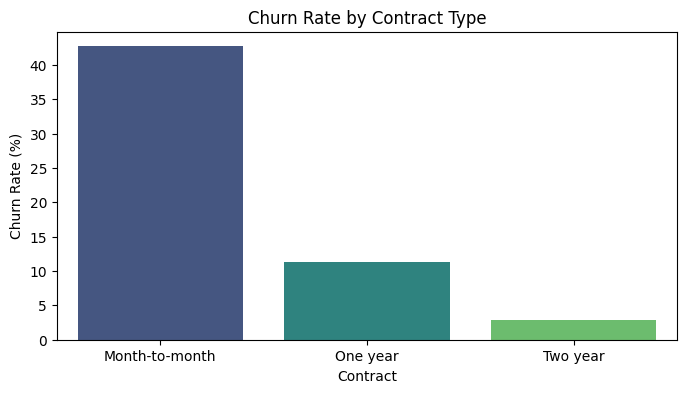

In [ ]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().reset_index()
contract_churn['Churn_Rate'] = contract_churn['Churn_Flag'] * 100

plt.figure(figsize=(8,4))
sns.barplot(x='Contract', y='Churn_Rate', data=contract_churn, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract')
plt.show()

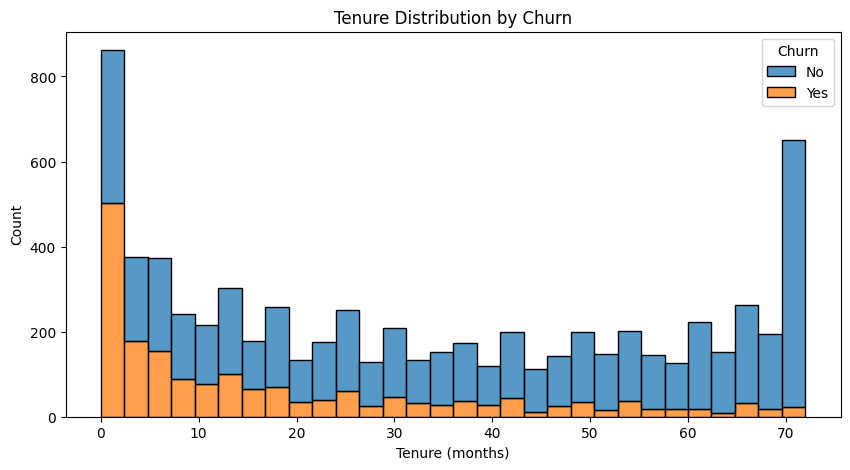

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

In [59]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 100],
    labels=['0-12', '12-24', '24-36', '36-48', '48-60', '60+']
)

tenure_churn = df.groupby('tenure_group', observed=False)['Churn_Flag'].mean() * 100
print(tenure_churn.sort_values())

tenure_group
60+       6.609808
48-60    14.423077
36-48    19.028871
24-36    21.634615
12-24    28.710938
0-12     47.678161
Name: Churn_Flag, dtype: float64


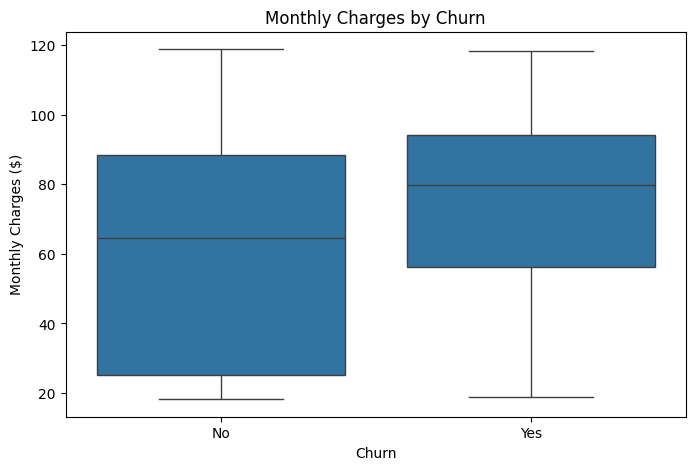

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [60]:
# Boxplot of MonthlyCharges by Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

# Compare median charges
df.groupby('Churn')['MonthlyCharges'].median()

In [61]:
print("""
Observations:
1. churn rate decreases as tenure increases
2. customers with longer tenure are less likely to churn
3. monthly charges have a significant impact on churn behavior
""")


Observations:
1. churn rate decreases as tenure increases
2. customers with longer tenure are less likely to churn
3. monthly charges have a significant impact on churn behavior



In [ ]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd
import numpy as np


X = df.drop(columns=['Churn', 'Churn_Flag', 'tenure_group'])  # drop target and auxiliary
y = df['Churn_Flag']

X = pd.get_dummies(X, drop_first=True)

# 2. Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # no scaling needed for tree models
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance_df.head(10))

Training set: (5634, 30), Test set: (1409, 30)

=== Logistic Regression ===
Accuracy: 0.8070
ROC-AUC: 0.8418
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[925 110]
 [162 212]]

=== Random Forest ===
Accuracy: 0.7928
ROC-AUC: 0.8264
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[926 109]
 [183 191]]

Top 10 Feature Importances:
                           Feature  Importance
3                     T

In [63]:
print('Recommendation: Implement targeted retention programs for month-to-month, new, and high-charge customers.')

Recommendation: Implement targeted retention programs for month-to-month, new, and high-charge customers.
